In [1]:
# Looking at the pepto images

In [58]:
import os
import numpy as np
import pandas as pd

# Define the root directory to start the search
root_dir = './'

# Initialize an empty list to store the data
data_list = []
data_names = []

# Loop through the directory tree
for subdir, _, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.npy'):
            file_path = os.path.join(subdir, file)
            # Load the .npy file
            data = np.load(file_path)
            # Append the data to the list
            data_list.append(data)
            data_names.append(file_path)

# # Convert the list to a pandas DataFrame
# df = pd.DataFrame(data_list)

# print(df)

In [59]:
# sort the data names and the data list using the same order
data_list = [x for _, x in sorted(zip(data_names, data_list))]
data_names = sorted(data_names)

In [60]:
data_list = np.array(data_list)

In [61]:
%pylab widget

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [62]:
import mpl_interactions as pli

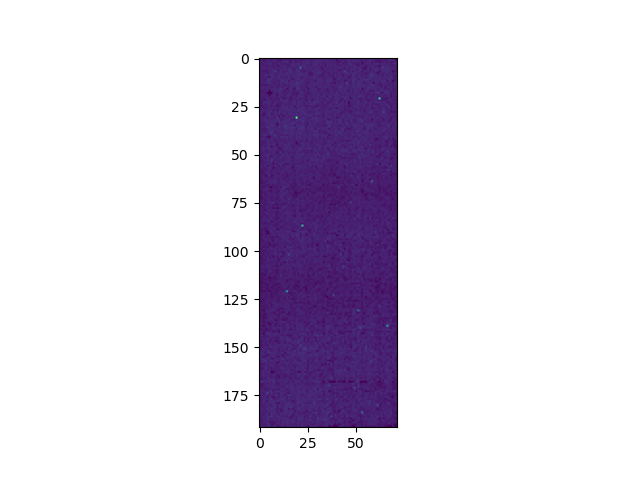

In [63]:
plt.figure()
pli.hyperslicer(data_list.squeeze()[:])

darks = data_list.squeeze()[7:14]
inverted = data_list.squeeze()[14:21]
flood = data_list.squeeze()[21:28]
clean_images = data_list.squeeze()[28:35]
second_inverted = data_list.squeeze()[35:42]
clean_again = data_list.squeeze()[42:49]


/tmp/ipykernel_26010/3907978501.py:57: RuntimeWarning: divide by zero encountered in divide
  corrected_image /= (flood_field)
/tmp/ipykernel_26010/3907978501.py:57: RuntimeWarning: invalid value encountered in divide
  corrected_image /= (flood_field)


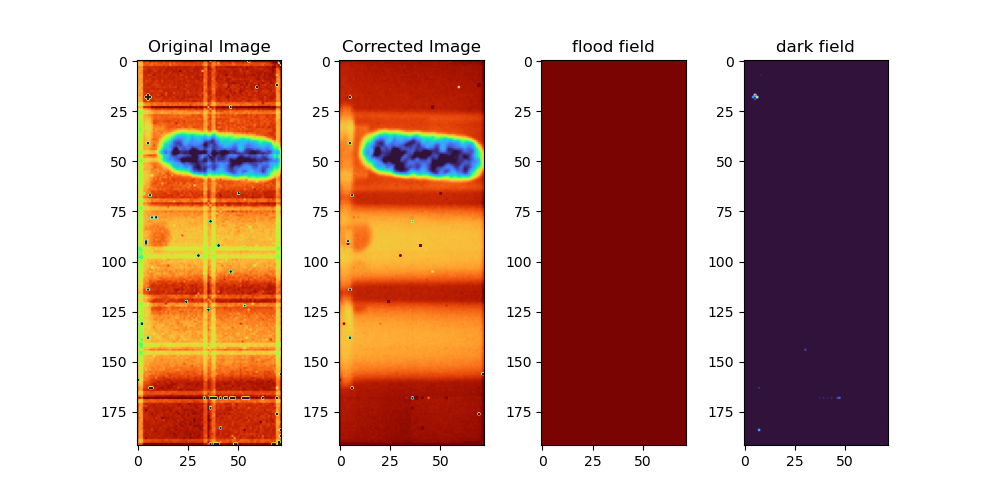

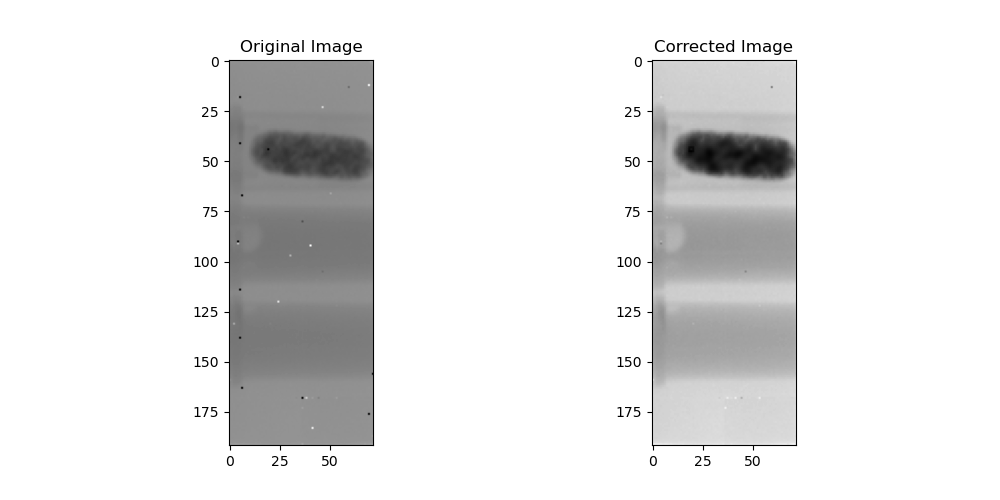

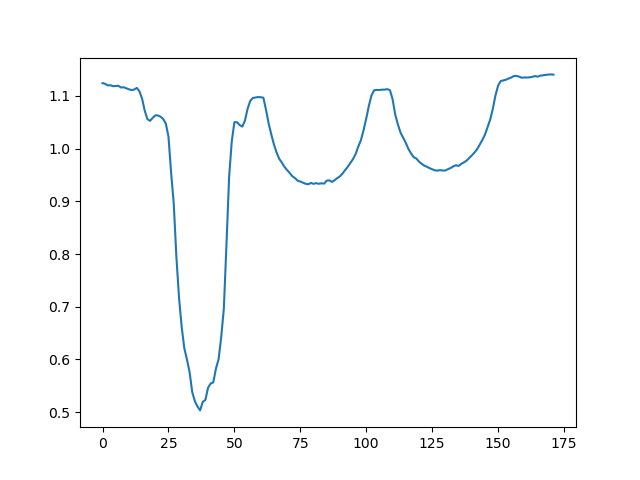

In [103]:
import numpy as np
import matplotlib.pyplot as plt

def detect_and_correct_pixels(image, dark_field, flood_field, lower_threshold, upper_threshold):
    """
    Detect and correct underresponding and overresponding pixels in an image using dark field and flood field images.
    
    Parameters:
    - image: 2D numpy array representing the target image.
    - dark_field: 2D numpy array representing the dark field image.
    - flood_field: 2D numpy array representing the flood field image.
    - lower_threshold: Threshold below which pixels are considered underresponding.
    - upper_threshold: Threshold above which pixels are considered overresponding.
    
    Returns:
    - corrected_image: Image with corrected pixels.
    """
    corrected_image = image.copy()
    
    # Detect underresponding and overresponding pixels
    underresponding_mask = image < lower_threshold
    overresponding_mask = image > upper_threshold
    
    # Get the indices of the pixels to be corrected
    underresponding_indices = np.argwhere(underresponding_mask)
    overresponding_indices = np.argwhere(overresponding_mask)
    
    # Function to calculate the mean of neighboring pixels
    def mean_of_neighbors(img, x, y):
        neighbors = []
        for i in range(max(0, x-1), min(img.shape[0], x+2)):
            for j in range(max(0, y-1), min(img.shape[1], y+2)):
                if (i, j) != (x, y):
                    neighbors.append(img[i, j])
        return np.mean(neighbors)
    
    # Correct underresponding pixels
    for x, y in underresponding_indices:
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    
    # Correct overresponding pixels
    for x, y in overresponding_indices:
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    
    return corrected_image

# Load your image data (replace with actual image loading code)
# For demonstration, we'll create synthetic images with some broken pixels
dark_field = darks[1]
flood_field = flood[1]
image = clean_images[1].copy()
# image[10, 10] = 0  # Underresponding pixel
# image[20, 20] = 255  # Overresponding pixel

corrected_image = image.copy()
corrected_image -= dark_field
corrected_image /= (flood_field)

corrected_image[corrected_image < 0] = 0
corrected_image[corrected_image > 2] = 2

corrected_image[np.isnan(corrected_image)] = 0

# Visualize the original and corrected images
plt.figure(figsize=(10, 5))
plt.subplot(1, 4, 1)
plt.title('Original Image')
plt.imshow(image, cmap='turbo',vmin = np.percentile(image, 1), vmax = np.percentile(image, 99))
plt.subplot(1, 4, 2)
plt.title('Corrected Image')
plt.imshow(corrected_image, cmap='turbo',vmin = np.percentile(corrected_image, 1), vmax = np.percentile(corrected_image, 99))
# plt.show()
plt.subplot(1, 4, 3)
plt.title('flood field')
plt.imshow(flood_field, cmap='turbo',vmin = np.percentile(corrected_image, 1), vmax = np.percentile(corrected_image, 99))
plt.subplot(1, 4, 4)
plt.title('dark field')
plt.imshow(dark_field, cmap='turbo')
plt.show()
import numpy as np
import matplotlib.pyplot as plt

def detect_and_correct_pixels(image, lower_threshold, upper_threshold):
    """
    Detect and correct underresponding and overresponding pixels in an image.
    
    Parameters:
    - image: 2D numpy array representing the image.
    - lower_threshold: Threshold below which pixels are considered underresponding.
    - upper_threshold: Threshold above which pixels are considered overresponding.
    
    Returns:
    - corrected_image: Image with corrected pixels.
    """
    corrected_image = image.copy()
    
    # Detect underresponding and overresponding pixels
    underresponding_mask = image < lower_threshold
    overresponding_mask = image > upper_threshold
    
    # Get the indices of the pixels to be corrected
    underresponding_indices = np.argwhere(underresponding_mask)
    overresponding_indices = np.argwhere(overresponding_mask)
    
    # Function to calculate the mean of neighboring pixels
    def mean_of_neighbors(img, x, y):
        neighbors = []
        for i in range(max(0, x-1), min(img.shape[0], x+2)):
            for j in range(max(0, y-1), min(img.shape[1], y+2)):
                if (i, j) != (x, y):
                    neighbors.append(img[i, j])
        return np.mean(neighbors)
    
    # Correct underresponding pixels
    for x, y in underresponding_indices:
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    
    # Correct overresponding pixels
    for x, y in overresponding_indices:
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    
    return corrected_image

# Load your image data (replace with actual image loading code)
# For demonstration, we'll create a synthetic image with some broken pixels
image = corrected_image.copy()

# Calculate mean and standard deviation of the image
mean = np.mean(image)
std = np.std(image)

# Define thresholds
lower_threshold = mean - 2.5 * std
upper_threshold = mean + 1.5 * std

# Detect and correct broken pixels
corrected_image2 = detect_and_correct_pixels(image, lower_threshold, upper_threshold)

# Visualize the original and corrected images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('Corrected Image')
plt.imshow(corrected_image2, cmap='gray')
plt.show()
plt.figure()
plt.plot(np.median(corrected_image[10:-10], axis = 1))

/tmp/ipykernel_26010/501232421.py:64: RuntimeWarning: invalid value encountered in divide
  corrected_image /= (flood_field)
/tmp/ipykernel_26010/501232421.py:64: RuntimeWarning: divide by zero encountered in divide
  corrected_image /= (flood_field)


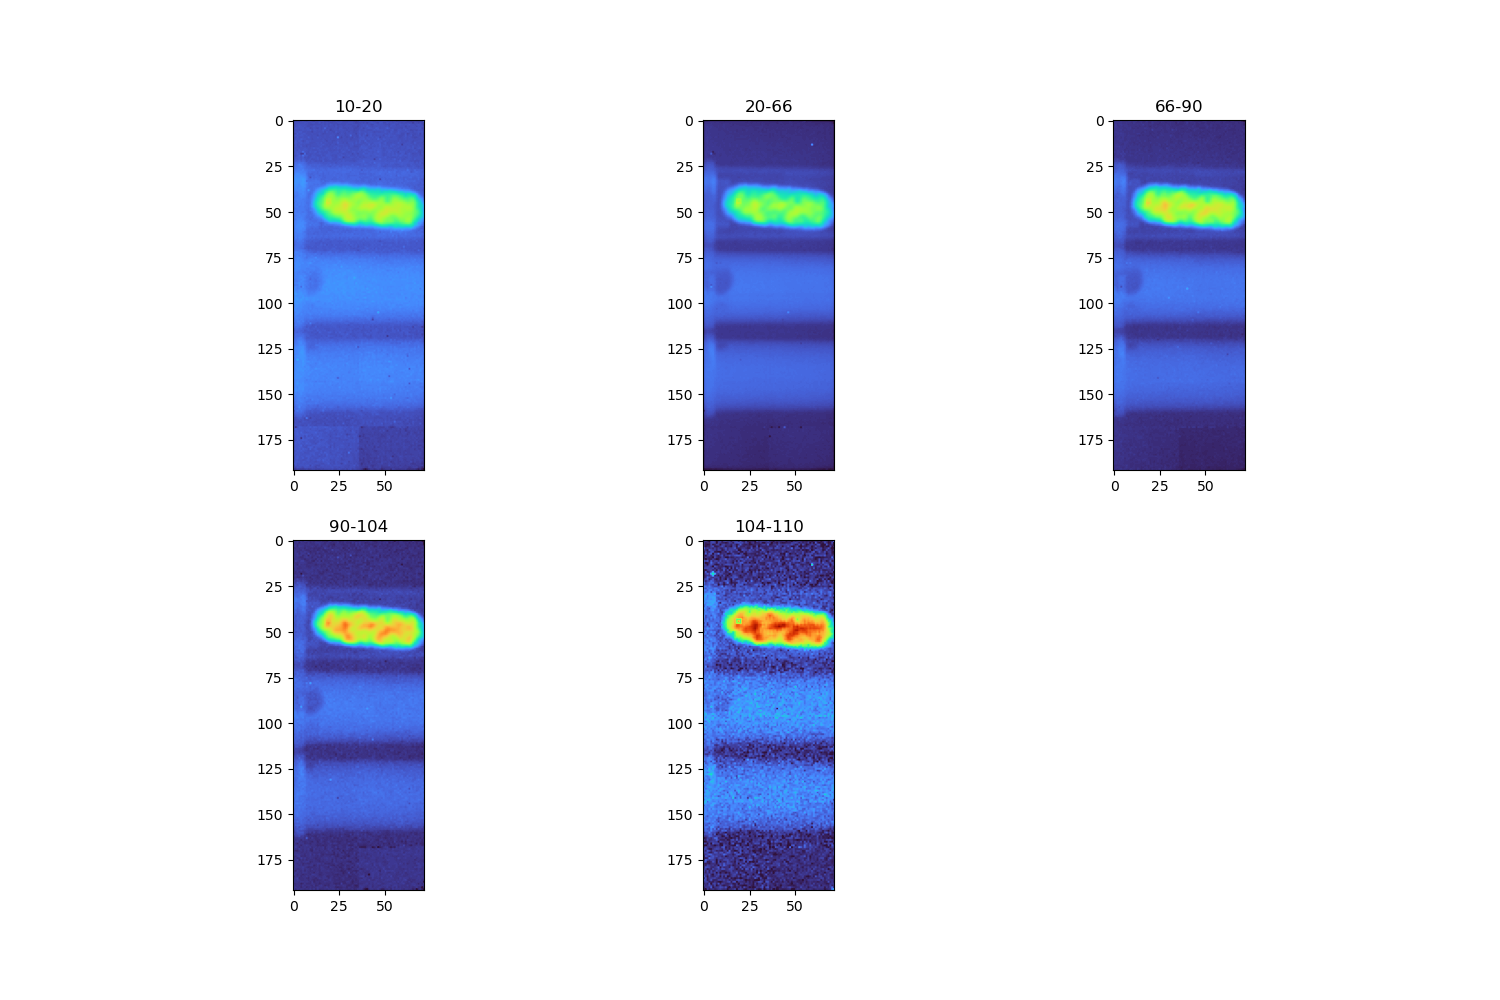

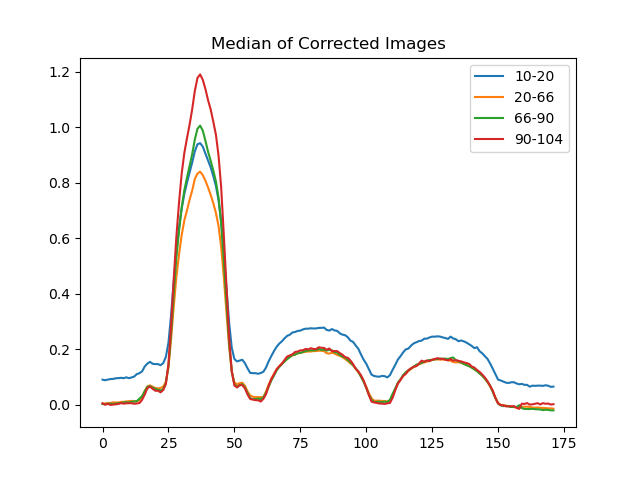

In [157]:
import numpy as np
import matplotlib.pyplot as plt


def detect_and_correct_pixels(image, lower_threshold, upper_threshold):
    """
    Detect and correct underresponding and overresponding pixels in an image.
    
    Parameters:
    - image: 2D numpy array representing the image.
    - lower_threshold: Threshold below which pixels are considered underresponding.
    - upper_threshold: Threshold above which pixels are considered overresponding.
    
    Returns:
    - corrected_image: Image with corrected pixels.
    """
    corrected_image = image.copy()
    
    # Detect underresponding and overresponding pixels
    underresponding_mask = image < lower_threshold
    overresponding_mask = image > upper_threshold
    
    # Get the indices of the pixels to be corrected
    underresponding_indices = np.argwhere(underresponding_mask)
    overresponding_indices = np.argwhere(overresponding_mask)
    
    # Function to calculate the mean of neighboring pixels
    def mean_of_neighbors(img, x, y):
        neighbors = []
        for i in range(max(0, x-1), min(img.shape[0], x+2)):
            for j in range(max(0, y-1), min(img.shape[1], y+2)):
                if (i, j) != (x, y):
                    neighbors.append(img[i, j])
        return np.mean(neighbors)
    
    # Correct underresponding pixels
    for x, y in underresponding_indices:
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    
    # Correct overresponding pixels
    for x, y in overresponding_indices:
        corrected_image[x, y] = mean_of_neighbors(image, x, y)
    
    return corrected_image

# Load your image data (replace with actual image loading code)
# For demonstration, we'll create synthetic images with some broken pixels
# Replace these with your actual data loading code
darks = data_list.squeeze()[7:13]
floods = data_list.squeeze()[21:27]
images = data_list.squeeze()[28:34]

# Correct the images
corrected_images = []
for i in range(6):
    dark_field = darks[i]
    flood_field = floods[i]
    image = images[i].copy()
    flood_field -= dark_field
    
    flood_field = flood_field/np.mean(flood_field[:15, 20:-20]) * np.mean(image[:15, 20:-20])
    corrected_image = image.copy()
    corrected_image -= dark_field
    corrected_image /= (flood_field)
    
    corrected_image[corrected_image < 0.1] = 0.1
    corrected_image[corrected_image > 2] = 2
    corrected_image[np.isnan(corrected_image)] = 0.1
    # Load your image data (replace with actual image loading code)
    # For demonstration, we'll create a synthetic image with some broken pixels
    image = corrected_image.copy()

    # Calculate mean and standard deviation of the image
    mean = np.mean(image)
    std = np.std(image)

    # Define thresholds
    lower_threshold = mean - 2 * std
    upper_threshold = mean + 1.5 * std

    # Detect and correct broken pixels
    corrected_image = detect_and_correct_pixels(image, lower_threshold, upper_threshold)
    corrected_images.append(-np.log(corrected_image))


bins = [20 , 30, 76, 100, 114, 120]
bins = np.array(bins)  - 10
# make names out of the bins
names = []
for i in range(len(bins)-1):
    names.append(f'{bins[i]}-{bins[i+1]}')
# Plot the median of the corrected images
plt.figure(figsize=(15, 10))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.title(names[i])
    plt.imshow(corrected_images[i], cmap='turbo', vmin=np.percentile(corrected_images[5], 1), vmax=np.percentile(corrected_images[5], 99))

plt.show()

# Plot the median of the corrected images along a specific axis

# define a standard scaler
def standardize(image):
    return (image - np.mean(image))/np.std(image)

plt.figure()
for i in range(4):
    plt.plot(np.mean(corrected_images[i][10:-10,15:-15], axis=1), label=names[i])
plt.legend()
plt.title('Median of Corrected Images')
plt.show()

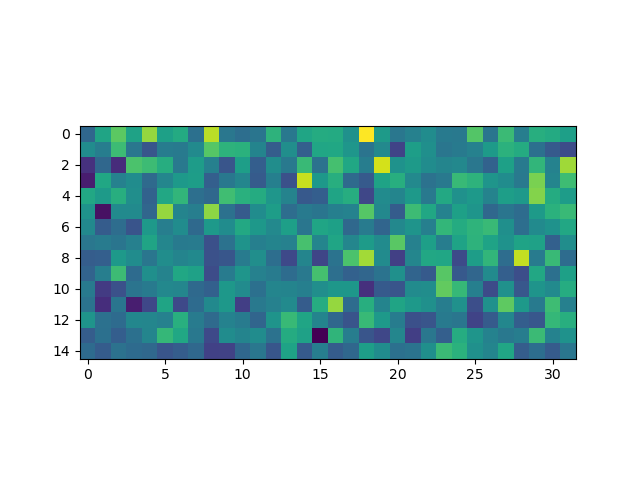

In [154]:
plt.figure()
plt.imshow(image[:15,20:-20])

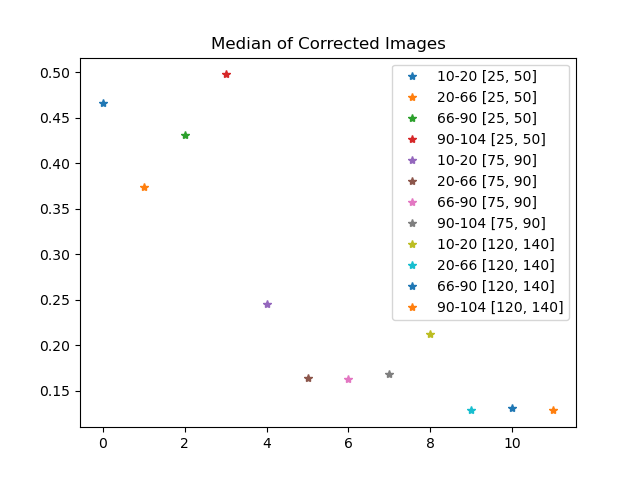

In [158]:
regions = [[25,50],[75,90],[120,140]]

# make a bar chart of the mean of the regions

values = []
plt.figure()
for i in range(3):
    for j in range(4):
        plt.plot(i*4 + j, np.mean(corrected_images[j][regions[i][0]:regions[i][1],10:-10]),'*', label=f'{names[j]} {regions[i]}')
        values.append(np.mean(corrected_images[j][regions[i][0]:regions[i][1],10:-10]))
plt.legend()
plt.title('Median of Corrected Images')
plt.show()

[0.46592462 0.37353931 0.43046845 0.49745542 0.24562583 0.16359828
 0.16321889 0.16866634 0.21262905 0.1284115  0.13063965 0.12939202]


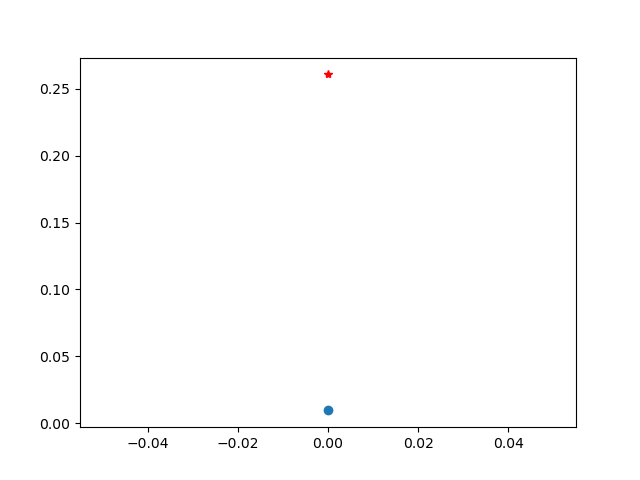

In [161]:
values = np.array(values)

plt.figure()
plt.plot(np.abs(values[-2] - values[-1])/values[-1], 'o')
plt.plot(np.abs(values[-5] - values[-4])/values[-5], 'r*')

print(values)